## LSTM - Results Summary

- **Model:** LSTM (two stacked layers)
- **Vocabulary size:** 50,000
- **Max sequence length:** 50
- **Embedding dim:** 128
- **Class weights:** balanced
- **Preprocessing:** lowercase, remove URLs, remove emojis

**Three architectures compared:**
- V1: hidden_size1=64,  hidden_size2=32, no Dropout
- V2: hidden_size1=128, hidden_size2=64, no Dropout  - selected
- V3: hidden_size1=128, hidden_size2=64, Dropout(0.2)

**Overall Test Results:**
- V2 (selected):  Macro F1 0.71  |  Accuracy 0.71
- V1:             Macro F1 0.70  |  Accuracy 0.70
- V3:             Macro F1 0.69  |  Accuracy 0.69

**Per-Language Results (V2 — selected):**
- Hausa  achieved a Macro F1 of 0.75 — beat LogReg (0.71 → 0.75)  - improved
- Igbo   achieved a Macro F1 of 0.75 — beat LogReg (0.73 → 0.75)  - improved
- Pidgin achieved a Macro F1 of 0.43 — still the worst (Pidgin neutral F1: 0.07)
- Yoruba achieved a Macro F1 of 0.69 — beat LogReg (0.68 → 0.69)  - improved

**Key Findings:**
- LSTM beat the LogReg baseline (0.71 vs 0.69)
- Beat LogReg on Hausa, Igbo, and Yoruba — gated memory works
- All three architectures vary across runs — no single dominant architecture
- V2 selected based on highest peak (0.713) across multiple runs
- Pidgin neutral still near-zero (F1: 0.07) — data problem, not model problem

**vs Logistic Regression Baseline:**
- Overall Macro F1:  0.71 vs 0.69  ← LSTM leads
- Hausa  F1:  0.75 vs 0.71         ← LSTM leads
- Igbo   F1:  0.75 vs 0.73         ← LSTM leads
- Pidgin F1:  0.43 vs 0.44         ← LogReg leads (marginal)
- Yoruba F1:  0.69 vs 0.68         ← LSTM leads

**LSTM beat the baseline on 3 out of 4 languages. AfroXLMR should push
all languages higher, including finally fixing Pidgin.**

In [1]:
# import the necessary libraries
import pandas as pd
import numpy as np
import re
import pickle

import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from utils import dataset_preprocessing, preparation_for_model_train, load_tokenizer

In [2]:
# load the datasets
df_train = pd.read_csv('../01-data/02-processed/train_clean.csv')
df_test = pd.read_csv('../01-data/02-processed/test_clean.csv')
df_val = pd.read_csv('../01-data/02-processed/val_clean.csv')

In [3]:
# drop tweet length from train dataset
df_train.drop(columns=['tweet_length'], inplace=True)

df_list = [df_train, df_test, df_val]
for df in df_list:
    df['cleaned_tweet'] = df['tweet'].apply(dataset_preprocessing)
    df.drop(columns=['tweet'], inplace=True)
    df.rename(columns={'cleaned_tweet': 'tweet'}, inplace=True)

In [4]:
# split dataset for training, validation and testing
X_train = df_train['tweet']
y_train = df_train['label']
X_test = df_test['tweet']
y_test = df_test['label']
X_val = df_val['tweet']
y_val = df_val['label']

In [5]:
tokenizer = load_tokenizer('../03-models/rnn_tokenizer.pkl')

X_train_pad, X_val_pad, X_test_pad, y_train, y_val, y_test, tokenizer = preparation_for_model_train(
    X_train, X_val, X_test, y_train, y_val, y_test, tokenizer=tokenizer
)

In [6]:
def build_simple_lstm_model(
    vocab_size=50000,
    embedding_dim=128,
    hidden_size1=64,
    hidden_size2=32,
    dropout_rate=None,
    **kwargs
):
    model = Sequential()

    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ))

    model.add(LSTM(
        units=hidden_size1,
        return_sequences=True,
        **kwargs
    ))

    if dropout_rate is not None:
        model.add(Dropout(dropout_rate))

    model.add(LSTM(
        units=hidden_size2,
        **kwargs
    ))

    if dropout_rate is not None:
        model.add(Dropout(dropout_rate))

    model.add(Dense(3, activation="softmax"))

    # compile the model
    model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    )

    return model

### LSTM Model V1

- Vocabulary size: 50,000
- Embedding layer: 128-dimensional word representations
- RNN Layer 1: 64 units (return_sequences=True)
- RNN Layer 2: 32 units
- Dropout: None
- Output layer: 3 units (softmax activation)

In [7]:
model = build_simple_lstm_model()

# compute and add class weights because of the limited 
# representation of the neutral sentiment for pidgin class
classes = np.array([0, 1, 2])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(enumerate(weights))

# Define early stopping and specify rollback, so it watches val loss and if it grows worse still after 3 epochs
# it stops and rollback

early_stop = EarlyStopping(
    monitor='val_loss',    # watch validation loss
    patience=3,            # wait 3 epochs before stopping
    restore_best_weights=True  # roll back to best epoch weights
)

# Then in model.fit:
history = model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop]
)

Epoch 1/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 91s 76ms/step - accuracy: 0.6730 - loss: 0.7402 - val_accuracy: 0.7321 - val_loss: 0.6386
Epoch 2/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 89s 78ms/step - accuracy: 0.8413 - loss: 0.4115 - val_accuracy: 0.7354 - val_loss: 0.6574
Epoch 3/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 140s 76ms/step - accuracy: 0.9282 - loss: 0.2047 - val_accuracy: 0.7219 - val_loss: 0.8198
Epoch 4/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 88s 77ms/step - accuracy: 0.9632 - loss: 0.1060 - val_accuracy: 0.7221 - val_loss: 1.0488


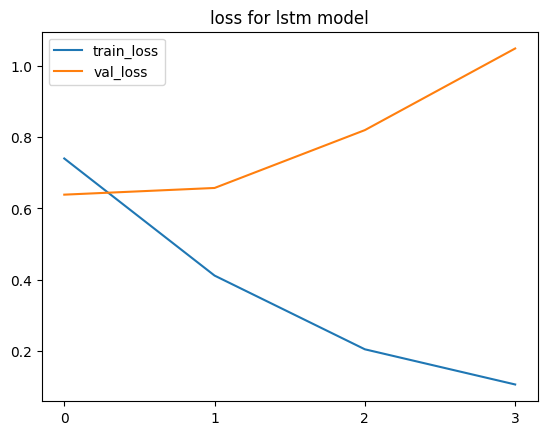

In [8]:
# plot the loss and validation loss
epochs_ran = len(history.history['loss'])

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xticks(np.arange(epochs_ran))
plt.title("loss for lstm model")
plt.legend()
plt.show()

In [9]:
predict = model.predict(X_test_pad)

y_pred = np.argmax(predict, axis=1)

f1 = f1_score(y_test, y_pred, average='macro')

print()
print()
print(f'f1_macro_lstm: {f1}')
print()
print()
print("="*50)
print('CLASSIFICATION REPORT FOR LSTM MODEL')
print("="*50)
print(classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))

552/552 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step


f1_macro_lstm: 0.7036892729424261


CLASSIFICATION REPORT FOR LSTM MODEL
              precision    recall  f1-score   support

    negative       0.62      0.81      0.70      6009
     neutral       0.73      0.64      0.68      5457
    positive       0.80      0.66      0.72      6188

    accuracy                           0.70     17654
   macro avg       0.72      0.70      0.70     17654
weighted avg       0.72      0.70      0.70     17654



### LSTM Model V2

- Vocabulary size: 50,000
- Embedding layer: 128-dimensional word representations
- RNN Layer 1: 128 units (return_sequences=True)
- RNN Layer 2: 64 units
- Dropout: None
- Output layer: 3 units (softmax activation)

In [10]:
model_v2 = build_simple_lstm_model(hidden_size1=128, hidden_size2=64)

# Then in model.fit:
history = model_v2.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop]
)

Epoch 1/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 100s 85ms/step - accuracy: 0.6691 - loss: 0.7476 - val_accuracy: 0.7317 - val_loss: 0.6329
Epoch 2/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 144s 86ms/step - accuracy: 0.8358 - loss: 0.4211 - val_accuracy: 0.7296 - val_loss: 0.6804
Epoch 3/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 98s 86ms/step - accuracy: 0.9237 - loss: 0.2135 - val_accuracy: 0.7140 - val_loss: 0.8089
Epoch 4/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 100s 87ms/step - accuracy: 0.9599 - loss: 0.1135 - val_accuracy: 0.7084 - val_loss: 1.0785


In [11]:
predict = model_v2.predict(X_test_pad)

y_pred = np.argmax(predict, axis=1)

f1 = f1_score(y_test, y_pred, average='macro')

print()
print()
print(f'f1_macro_lstm_v2: {f1}')
print()
print()
print("="*50)
print('CLASSIFICATION REPORT FOR LSTM MODEL v2')
print("="*50)
print(classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))

552/552 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step


f1_macro_lstm_v2: 0.7126111019928955


CLASSIFICATION REPORT FOR LSTM MODEL v2
              precision    recall  f1-score   support

    negative       0.66      0.76      0.71      6009
     neutral       0.70      0.68      0.69      5457
    positive       0.78      0.70      0.74      6188

    accuracy                           0.71     17654
   macro avg       0.72      0.71      0.71     17654
weighted avg       0.72      0.71      0.71     17654



### LSTM Model V3

- Vocabulary size: 50,000
- Embedding layer: 128-dimensional word representations
- RNN Layer 1: 128 units (return_sequences=True)
- RNN Layer 2: 64 units
- Dropout: 0.2
- Output layer: 3 units (softmax activation)

In [12]:
model_v3 = build_simple_lstm_model(hidden_size1=128, hidden_size2=64, dropout_rate=0.2)

# Then in model.fit:
history = model_v3.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop]
)

Epoch 1/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 108s 91ms/step - accuracy: 0.6650 - loss: 0.7472 - val_accuracy: 0.7155 - val_loss: 0.6581
Epoch 2/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 114s 100ms/step - accuracy: 0.8380 - loss: 0.4191 - val_accuracy: 0.7359 - val_loss: 0.6550
Epoch 3/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 159s 115ms/step - accuracy: 0.9223 - loss: 0.2148 - val_accuracy: 0.7179 - val_loss: 0.8427


In [13]:
predict = model_v3.predict(X_test_pad)

y_pred = np.argmax(predict, axis=1)

f1 = f1_score(y_test, y_pred, average='macro')

print()
print()
print(f'f1_macro_lstm_v3: {f1}')
print()
print()
print("="*50)
print('CLASSIFICATION REPORT FOR LSTM MODEL v3')
print("="*50)
print(classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))

552/552 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step


f1_macro_lstm_v3: 0.6918093054043553


CLASSIFICATION REPORT FOR LSTM MODEL v3
              precision    recall  f1-score   support

    negative       0.59      0.84      0.70      6009
     neutral       0.74      0.61      0.67      5457
    positive       0.84      0.62      0.71      6188

    accuracy                           0.69     17654
   macro avg       0.72      0.69      0.69     17654
weighted avg       0.72      0.69      0.69     17654



In [14]:
reverse_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
predict = model_v2.predict(X_test_pad)
y_pred = np.argmax(predict, axis=1)
df_test['predicted'] = y_pred
df_test['predicted'] = df_test['predicted'].map(reverse_mapping)

for lang in ['hausa', 'igbo', 'pidgin', 'yoruba']:
    subset = df_test[df_test['language'] == lang]
    print(f"\n{'='*50}")
    print(f"Language: {lang.upper()}")
    print(f"{'='*50}")
    print(classification_report(subset['label'], subset['predicted'],
                                target_names=['negative','neutral','positive']))

552/552 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step

Language: HAUSA
              precision    recall  f1-score   support

    negative       0.73      0.70      0.71      1759
     neutral       0.69      0.71      0.70      1789
    positive       0.82      0.83      0.82      1755

    accuracy                           0.75      5303
   macro avg       0.75      0.75      0.75      5303
weighted avg       0.74      0.75      0.74      5303


Language: IGBO
              precision    recall  f1-score   support

    negative       0.70      0.68      0.69       943
     neutral       0.77      0.75      0.76      1621
    positive       0.78      0.84      0.81      1118

    accuracy                           0.76      3682
   macro avg       0.75      0.76      0.75      3682
weighted avg       0.76      0.76      0.76      3682


Language: PIDGIN
              precision    recall  f1-score   support

    negative       0.64      0.91      0.75      2326
     neutral       0.26      0.04  

In [17]:
# save the selected model (V2) to the models folder
model_v2.save('../03-models/lstm_v2.keras')
print("model saved to 03-models/lstm_v2.keras")

model saved to 03-models/lstm_v2.keras
